In [1]:
import sys
import os
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Make model/ and parameter_scan/ importable (if running from parameter_scan/)
sys.path.insert(0, os.path.abspath('../../model'))
sys.path.insert(0, os.path.abspath('../.'))

In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import xso

from np_setups import (
    phyto_esd, zoo_esd, n_classes, n_zoo,
    model_open,
    model_npz_typeII, model_npz_typeIII,
    model_setup_open_const,
    model_setup_npz_typeII_matched,
    model_setup_npz_typeII_herb,
    model_setup_npz_typeII_omni,
    model_setup_npz_typeIII_matched,
    model_setup_npz_typeIII_herb,
    model_setup_npz_typeIII_omni,
)

F_N_ANCHOR = 15.0      # mmol N m-2 d-1
SS_FLOOR   = 1e-12     # positive floor for fsolve seed (avoid zeros / negatives)

# (label, model_context, ivp_setup_object)
RUNS_SPEC = [
    ('NP — open chemostat',     model_open,        model_setup_open_const),
    ('NPZ TypeII — matched',    model_npz_typeII,  model_setup_npz_typeII_matched),
    ('NPZ TypeII — herbivory',  model_npz_typeII,  model_setup_npz_typeII_herb),
    ('NPZ TypeII — omnivory',   model_npz_typeII,  model_setup_npz_typeII_omni),
    ('NPZ TypeIII — matched',   model_npz_typeIII, model_setup_npz_typeIII_matched),
    ('NPZ TypeIII — herbivory', model_npz_typeIII, model_setup_npz_typeIII_herb),
    ('NPZ TypeIII — omnivory',  model_npz_typeIII, model_setup_npz_typeIII_omni),
]


def last_finite_time_index(ivp_out, state_vars):
    """Last time index where every listed state variable is finite (no NaN/inf).
    Returns None if the IVP produced no valid data at all."""
    all_finite = np.ones(ivp_out.sizes['time'], dtype=bool)
    for v in state_vars:
        arr = ivp_out[v].values
        non_time_axes = tuple(i for i, d in enumerate(ivp_out[v].dims) if d != 'time')
        var_finite = (np.all(np.isfinite(arr), axis=non_time_axes)
                      if non_time_axes else np.isfinite(arr))
        all_finite &= var_finite
    good = np.where(all_finite)[0]
    return int(good[-1]) if len(good) else None


# runs[label] = (ivp_out, ss_out); ss_out is None if no valid fsolve seed.
runs = {}
print(f"F_N = {F_N_ANCHOR} mmol N m-2 d-1\n")
print(f"{'variant':<28s}   {'IVP':>8s}   {'fsolve':>8s}   {'seed-t':>7s}")
print("-" * 64)

for label, mod, ivp_setup in RUNS_SPEC:
    is_npz = 'NPZ' in label
    state_vars = ['Nutrient__value', 'Phytoplankton__biomass']
    if is_npz:
        state_vars.append('Zooplankton__biomass')

    # --- 1. IVP transient ---
    t0 = time.time()
    with mod:
        ivp_out = (ivp_setup
                   .xsimlab.update_vars(input_vars={'FN_Forcing': {'value': F_N_ANCHOR}})
                   .xsimlab.run())
    t_ivp = time.time() - t0

    # --- 2. Seed fsolve from last finite IVP state (positive-clipped) ---
    last_idx = last_finite_time_index(ivp_out, state_vars)
    if last_idx is None or last_idx < 1:
        print(f"{label:<28s}   {t_ivp:6.2f} s     ----      ----   "
              f"(no valid seed for fsolve)")
        runs[label] = (ivp_out, None)
        continue

    seed_vars = {
        'FN_Forcing':    {'value': F_N_ANCHOR},
        'Nutrient':      {'value_init': max(
            float(ivp_out.Nutrient__value.isel(time=last_idx)), SS_FLOOR)},
        'Phytoplankton': {'biomass_init': np.maximum(
            ivp_out.Phytoplankton__biomass.isel(time=last_idx).values, SS_FLOOR)},
    }
    if is_npz:
        seed_vars['Zooplankton'] = {'biomass_init': np.maximum(
            ivp_out.Zooplankton__biomass.isel(time=last_idx).values, SS_FLOOR)}

    # --- 3. Derive fsolve setup from the IVP setup via update_setup ---
    fsolve_setup = xso.update_setup(
        model=mod, old_setup=ivp_setup,
        new_solver='fsolve', new_time=[0, 1],
    )

    # --- 4. Inject the seed + the F_N anchor and run fsolve ---
    t1 = time.time()
    with mod:
        ss_out = (fsolve_setup
                  .xsimlab.update_vars(input_vars=seed_vars)
                  .xsimlab.run())
    t_ss = time.time() - t1

    seed_t_d = ivp_out.time.values[last_idx]
    print(f"{label:<28s}   {t_ivp:6.2f} s   {t_ss:6.2f} s   {seed_t_d:5.0f} d")
    runs[label] = (ivp_out, ss_out)

print(f"\nDone. IVP integrations span 0 - {runs[RUNS_SPEC[0][0]][0].time.values[-1]:.0f} d.")

F_N = 15.0 mmol N m-2 d-1

variant                             IVP     fsolve    seed-t
----------------------------------------------------------------
NP — open chemostat              0.19 s     0.03 s    4999 d
NPZ TypeII — matched           132.03 s     0.14 s    4999 d
NPZ TypeII — herbivory          46.93 s     0.10 s    4999 d
NPZ TypeII — omnivory          127.19 s     0.07 s    4999 d
NPZ TypeIII — matched          172.35 s     0.07 s    4999 d
NPZ TypeIII — herbivory         58.03 s     0.11 s    4999 d
NPZ TypeIII — omnivory          52.33 s     0.07 s    4999 d

Done. IVP integrations span 0 - 4999 d.


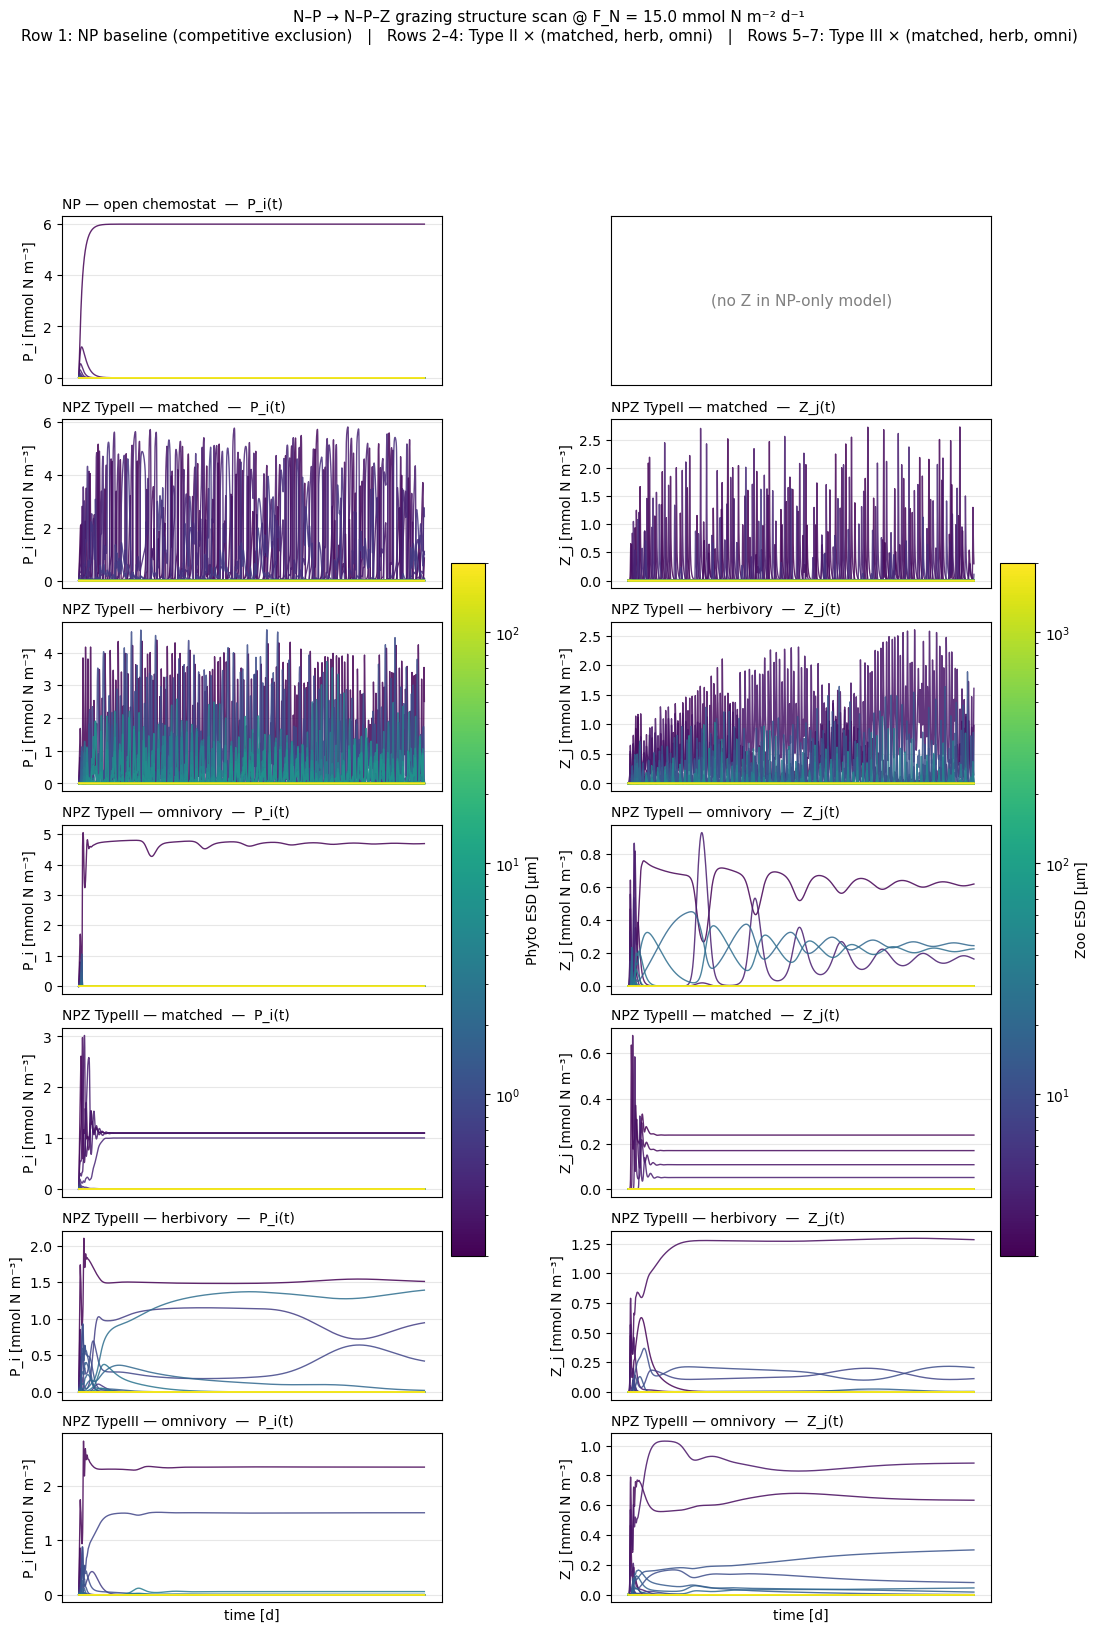

In [5]:
fig, axes = plt.subplots(7, 2, figsize=(13, 18), sharex=True)

cmap   = plt.get_cmap('viridis')
norm_P = mcolors.LogNorm(vmin=phyto_esd.min(), vmax=phyto_esd.max())
norm_Z = mcolors.LogNorm(vmin=zoo_esd.min(),   vmax=zoo_esd.max())

for row, (label, _, _) in enumerate(RUNS_SPEC):
    ivp_out, _ = runs[label]
    t   = ivp_out.time.values

    # --- P column (always populated)
    ax_P = axes[row, 0]
    P_t  = ivp_out.Phytoplankton__biomass.transpose('time', 'phyto').values
    for i in range(n_classes):
        ax_P.plot(t, P_t[:, i], color=cmap(norm_P(phyto_esd[i])),
                  alpha=0.85, lw=1)
    ax_P.set_title(f'{label}  —  P_i(t)', fontsize=10, loc='left')
    ax_P.set_ylabel('P_i [mmol N m⁻³]')
    ax_P.grid(True, alpha=0.3)

    # --- Z column (NP row is blank)
    ax_Z = axes[row, 1]
    if 'NPZ' in label:
        Z_t = ivp_out.Zooplankton__biomass.transpose('time', 'zoo').values
        for j in range(n_zoo):
            ax_Z.plot(t, Z_t[:, j], color=cmap(norm_Z(zoo_esd[j])),
                      alpha=0.85, lw=1)
        ax_Z.set_title(f'{label}  —  Z_j(t)', fontsize=10, loc='left')
        ax_Z.set_ylabel('Z_j [mmol N m⁻³]')
        ax_Z.grid(True, alpha=0.3)
    else:
        ax_Z.text(0.5, 0.5, '(no Z in NP-only model)',
                  transform=ax_Z.transAxes,
                  ha='center', va='center', color='gray', fontsize=11)
        ax_Z.set_xticks([])
        ax_Z.set_yticks([])

axes[-1, 0].set_xlabel('time [d]')
axes[-1, 1].set_xlabel('time [d]')

sm_P = plt.cm.ScalarMappable(norm=norm_P, cmap=cmap)
sm_Z = plt.cm.ScalarMappable(norm=norm_Z, cmap=cmap)
fig.colorbar(sm_P, ax=axes[:, 0].tolist(), label='Phyto ESD [µm]',
             shrink=0.5, pad=0.02)
fig.colorbar(sm_Z, ax=axes[:, 1].tolist(), label='Zoo ESD [µm]',
             shrink=0.5, pad=0.02)

fig.suptitle(
    f'N–P → N–P–Z grazing structure scan @ F_N = {F_N_ANCHOR} mmol N m⁻² d⁻¹\n'
    f'Row 1: NP baseline (competitive exclusion)   |   '
    f'Rows 2–4: Type II × (matched, herb, omni)   |   '
    f'Rows 5–7: Type III × (matched, herb, omni)',
    fontsize=11, y=0.995)
plt.show()

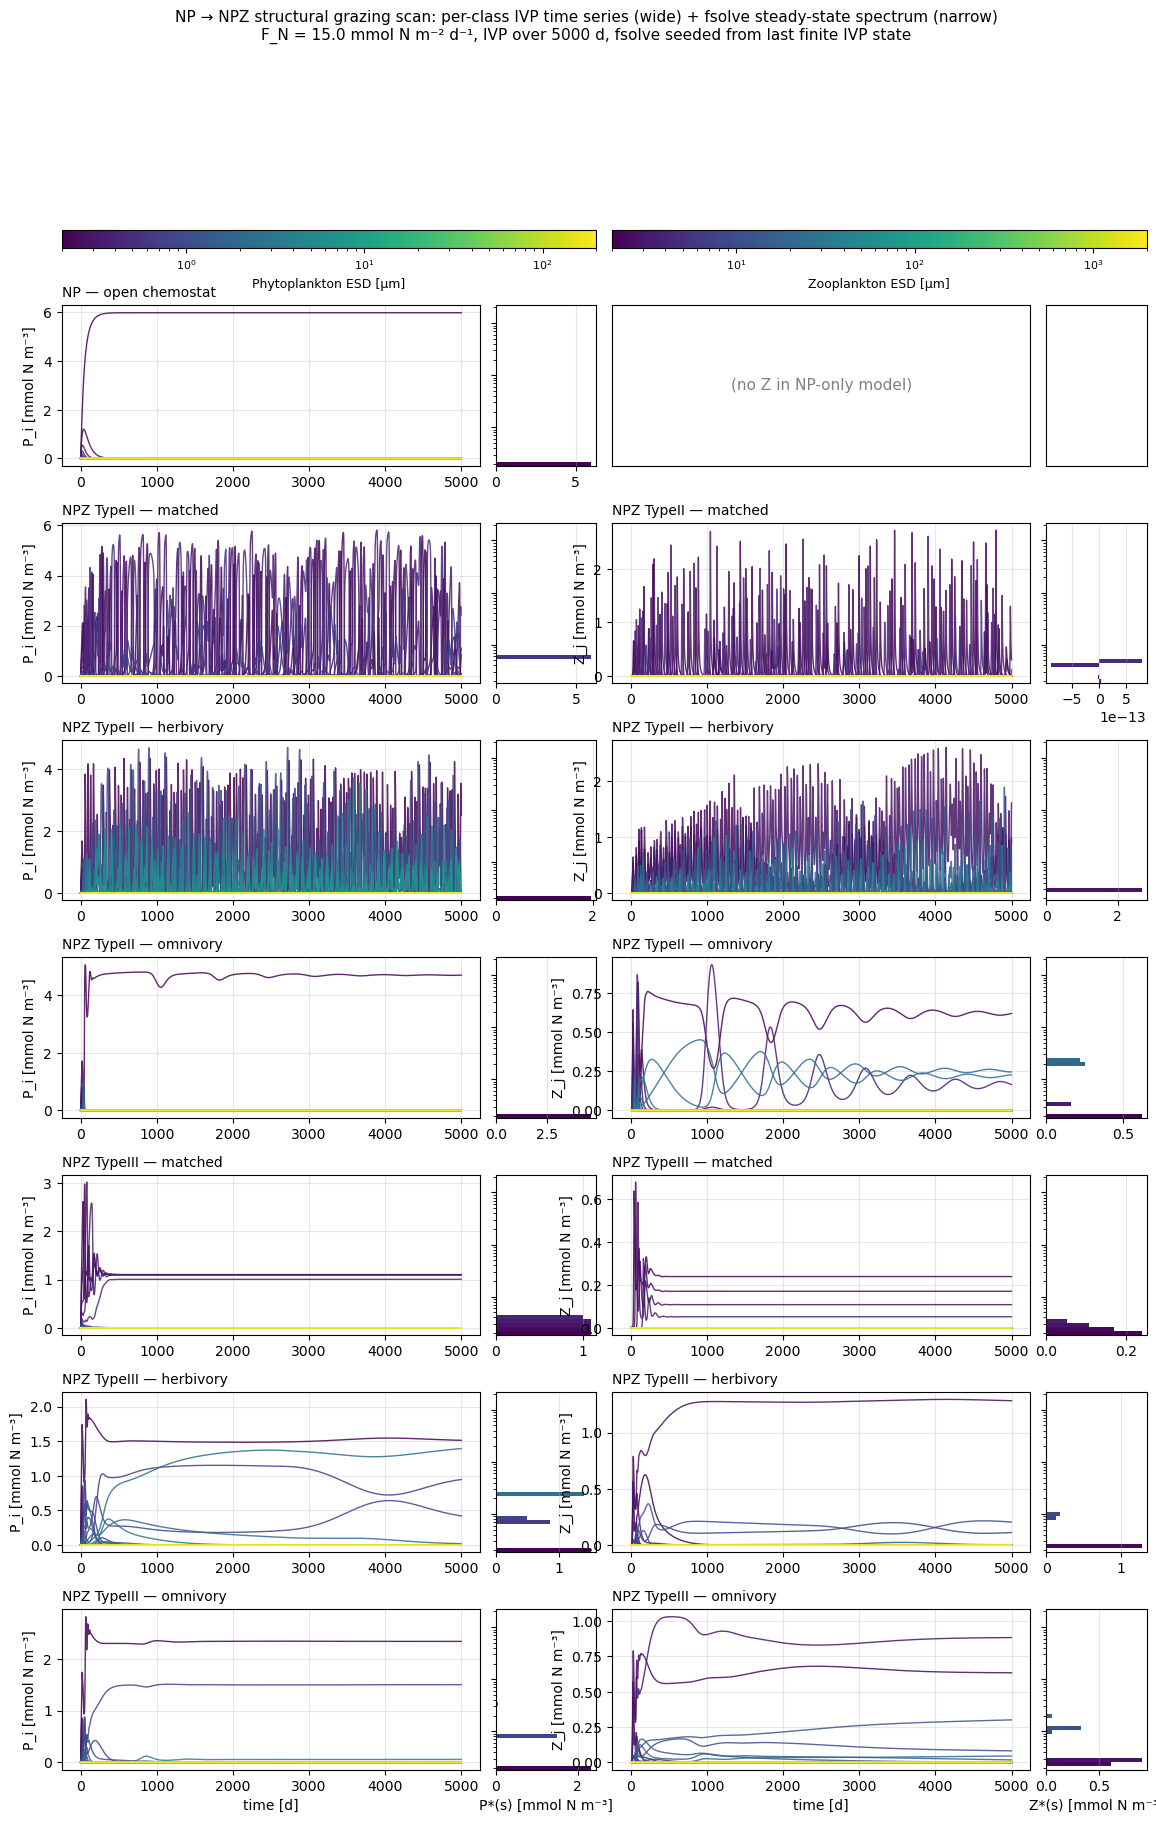

In [6]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(14, 20))
gs = GridSpec(
    nrows=1 + 7, ncols=4,
    width_ratios=[5, 1.2, 5, 1.2],
    height_ratios=[0.35] + [3] * 7,
    hspace=0.40, wspace=0.06,
    figure=fig,
)

cmap   = plt.get_cmap('viridis')
norm_P = mcolors.LogNorm(vmin=phyto_esd.min(), vmax=phyto_esd.max())
norm_Z = mcolors.LogNorm(vmin=zoo_esd.min(),   vmax=zoo_esd.max())
colors_P = [cmap(norm_P(s)) for s in phyto_esd]
colors_Z = [cmap(norm_Z(s)) for s in zoo_esd]

# Top horizontal colorbars
cax_P = fig.add_subplot(gs[0, 0:2])
cax_Z = fig.add_subplot(gs[0, 2:4])
fig.colorbar(plt.cm.ScalarMappable(norm=norm_P, cmap=cmap),
             cax=cax_P, orientation='horizontal').set_label(
    'Phytoplankton ESD [µm]', fontsize=9)
fig.colorbar(plt.cm.ScalarMappable(norm=norm_Z, cmap=cmap),
             cax=cax_Z, orientation='horizontal').set_label(
    'Zooplankton ESD [µm]', fontsize=9)
cax_P.tick_params(labelsize=8)
cax_Z.tick_params(labelsize=8)

# Bar heights for spectrum panels (log-spaced grid)
esd_ratio_P = phyto_esd[1] / phyto_esd[0]
esd_ratio_Z = zoo_esd[1]   / zoo_esd[0]
hfac_P = np.sqrt(esd_ratio_P) - 1.0 / np.sqrt(esd_ratio_P)
hfac_Z = np.sqrt(esd_ratio_Z) - 1.0 / np.sqrt(esd_ratio_Z)
heights_P = phyto_esd * hfac_P
heights_Z = zoo_esd   * hfac_Z

for row_idx, (label, _, _) in enumerate(RUNS_SPEC):
    gs_row  = row_idx + 1
    ax_P_ts = fig.add_subplot(gs[gs_row, 0])
    ax_P_sp = fig.add_subplot(gs[gs_row, 1])
    ax_Z_ts = fig.add_subplot(gs[gs_row, 2])
    ax_Z_sp = fig.add_subplot(gs[gs_row, 3])

    ivp_out, ss_out = runs[label]
    t      = ivp_out.time.values
    is_npz = 'NPZ' in label

    # P time series (IVP transient)
    P_t = ivp_out.Phytoplankton__biomass.transpose('time', 'phyto').values
    for i in range(n_classes):
        ax_P_ts.plot(t, P_t[:, i], color=colors_P[i], alpha=0.85, lw=1)
    ax_P_ts.set_title(label, fontsize=10, loc='left')
    ax_P_ts.set_ylabel('P_i [mmol N m⁻³]')
    ax_P_ts.grid(True, alpha=0.3)

    # P steady-state spectrum (fsolve at time=-1)
    if ss_out is not None:
        P_ss = ss_out.Phytoplankton__biomass.isel(time=-1).values
        ax_P_sp.barh(phyto_esd, P_ss, height=heights_P,
                     color=colors_P, edgecolor='none')
    else:
        ax_P_sp.text(0.5, 0.5, '(no fsolve)', transform=ax_P_sp.transAxes,
                     ha='center', va='center', color='gray', fontsize=8)
    ax_P_sp.set_yscale('log')
    ax_P_sp.set_ylim(phyto_esd[0]  / np.sqrt(esd_ratio_P),
                     phyto_esd[-1] * np.sqrt(esd_ratio_P))
    ax_P_sp.tick_params(axis='y', labelleft=False)
    ax_P_sp.grid(True, alpha=0.3, axis='x')

    # Z column (blank for NP-only)
    if is_npz:
        Z_t = ivp_out.Zooplankton__biomass.transpose('time', 'zoo').values
        for j in range(n_zoo):
            ax_Z_ts.plot(t, Z_t[:, j], color=colors_Z[j], alpha=0.85, lw=1)
        ax_Z_ts.set_title(label, fontsize=10, loc='left')
        ax_Z_ts.set_ylabel('Z_j [mmol N m⁻³]')
        ax_Z_ts.grid(True, alpha=0.3)

        if ss_out is not None:
            Z_ss = ss_out.Zooplankton__biomass.isel(time=-1).values
            ax_Z_sp.barh(zoo_esd, Z_ss, height=heights_Z,
                         color=colors_Z, edgecolor='none')
        else:
            ax_Z_sp.text(0.5, 0.5, '(no fsolve)', transform=ax_Z_sp.transAxes,
                         ha='center', va='center', color='gray', fontsize=8)
        ax_Z_sp.set_yscale('log')
        ax_Z_sp.set_ylim(zoo_esd[0]  / np.sqrt(esd_ratio_Z),
                         zoo_esd[-1] * np.sqrt(esd_ratio_Z))
        ax_Z_sp.tick_params(axis='y', labelleft=False)
        ax_Z_sp.grid(True, alpha=0.3, axis='x')
    else:
        ax_Z_ts.text(0.5, 0.5, '(no Z in NP-only model)',
                     transform=ax_Z_ts.transAxes,
                     ha='center', va='center', color='gray', fontsize=11)
        for ax in (ax_Z_ts, ax_Z_sp):
            ax.set_xticks([]); ax.set_yticks([])

    if row_idx == len(RUNS_SPEC) - 1:
        ax_P_ts.set_xlabel('time [d]')
        ax_P_sp.set_xlabel('P*(s) [mmol N m⁻³]')
        if is_npz:
            ax_Z_ts.set_xlabel('time [d]')
            ax_Z_sp.set_xlabel('Z*(s) [mmol N m⁻³]')

fig.suptitle(
    'NP → NPZ structural grazing scan: per-class IVP time series (wide) '
    '+ fsolve steady-state spectrum (narrow)\n'
    f'F_N = {F_N_ANCHOR} mmol N m⁻² d⁻¹, IVP over 5000 d, '
    'fsolve seeded from last finite IVP state',
    fontsize=11, y=0.99,
)
plt.show()

=== Check 1: oscillation amplitude (95-5 pct range), first vs last quarter ===
  active P[3] (ESD=  0.34 µm): q1=5.28, q4=4.62, ratio q4/q1=0.87
  active Z[0] (ESD=  2.00 µm): q1=0.926, q4=0.831, ratio q4/q1=0.90
  ratio >>1 = growing oscillation (concerning); ~1 = sustained limit cycle (physical); <1 = damping toward equilibrium


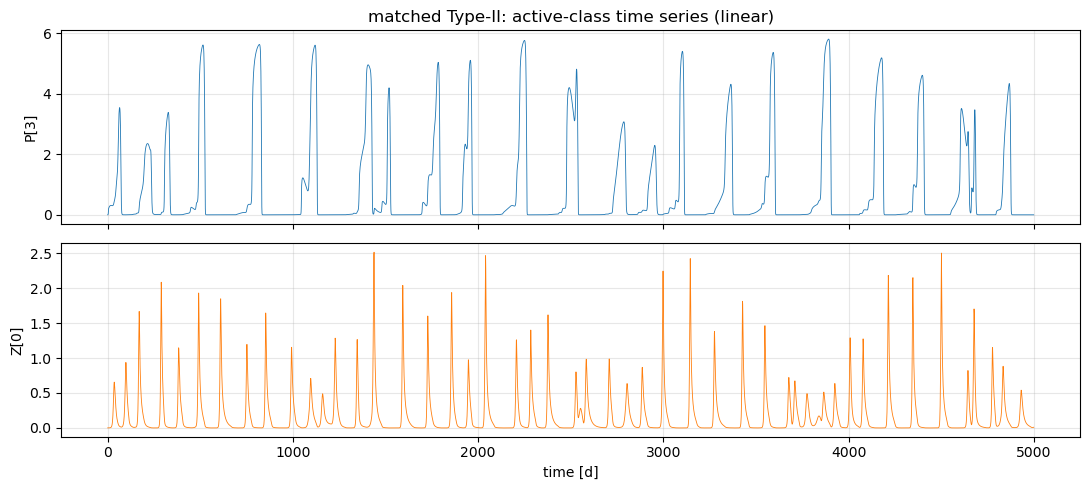


=== Check 2: fsolve spectrum structure ===
  fsolve N         : 0.02853
  P |val| bins     : >1e-3:  1  1e-6..1e-3:  0  1e-9..1e-6:  0  ≤1e-9: 39
  Z |val| bins     : >1e-3:  0  1e-6..1e-3:  0  1e-9..1e-6:  0  ≤1e-9: 40
  P |max|, signed  : |5.97|, max=+5.97, min=-5.13e-12
  Z |max|, signed  : |8.98e-13|, max=+7.89e-13, min=-8.98e-13

  If 'Z |val| bins > 1e-6' has any nonzero entries, masking |Z|<1e-9 keeps those
  and only suppresses the noise floor. If it's all zero, fsolve really did
  put all Z classes at floor for this case.

=== Check 3: IVP tail-mean (last 500d) vs fsolve, active classes only ===
  (For a sustained limit cycle, fsolve should approximate the IVP long-time mean.)
  Active P classes (|val|>1e-6 in either):
    P[ 0] (ESD=  0.20µm): tail-mean=+5.887e-01, fsolve=+2.384e-15, diff=+5.89e-01
    P[ 1] (ESD=  0.24µm): tail-mean=+9.442e-01, fsolve=+2.051e-15, diff=+9.44e-01
    P[ 2] (ESD=  0.29µm): tail-mean=+6.929e-01, fsolve=-2.021e-19, diff=+6.93e-01
    P[ 3] (ESD=

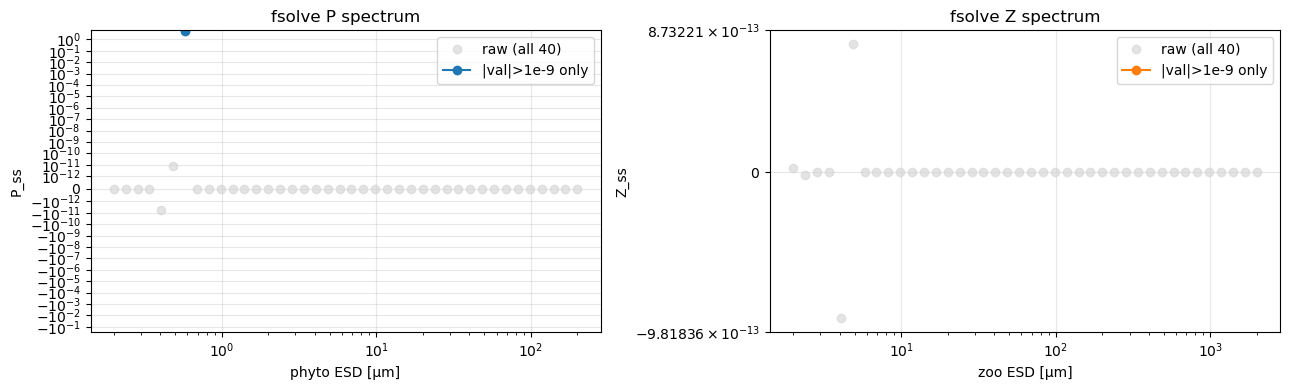

In [7]:
# Diagnose matched-Type-II: oscillation character + fsolve spectrum structure.

import numpy as np
import matplotlib.pyplot as plt
from np_setups import phyto_esd, zoo_esd

label = 'NPZ TypeII — matched'
ivp_out, ss_out = runs[label]
t = ivp_out.time.values

# Pick the most active P and Z classes (largest time-averaged biomass).
i_P = ivp_out.Phytoplankton__biomass.mean('time').argmax().item()
j_Z = ivp_out.Zooplankton__biomass.mean('time').argmax().item()
P_i = ivp_out.Phytoplankton__biomass.isel(phyto=i_P).values
Z_j = ivp_out.Zooplankton__biomass.isel(zoo=j_Z).values


# === CHECK 1: bounded limit cycle vs growing oscillation =====================
def amp(x):
    return float(np.percentile(x, 95) - np.percentile(x, 5))

n = len(t)
amp_P_q1, amp_P_q4 = amp(P_i[:n//4]), amp(P_i[-n//4:])
amp_Z_q1, amp_Z_q4 = amp(Z_j[:n//4]), amp(Z_j[-n//4:])

print(f"=== Check 1: oscillation amplitude (95-5 pct range), first vs last quarter ===")
print(f"  active P[{i_P}] (ESD={phyto_esd[i_P]:6.2f} µm): "
      f"q1={amp_P_q1:.3g}, q4={amp_P_q4:.3g}, ratio q4/q1={amp_P_q4/max(amp_P_q1,1e-30):.2f}")
print(f"  active Z[{j_Z}] (ESD={zoo_esd[j_Z]:6.2f} µm): "
      f"q1={amp_Z_q1:.3g}, q4={amp_Z_q4:.3g}, ratio q4/q1={amp_Z_q4/max(amp_Z_q1,1e-30):.2f}")
print(f"  ratio >>1 = growing oscillation (concerning); "
      f"~1 = sustained limit cycle (physical); <1 = damping toward equilibrium")

fig, (axP, axZ) = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
axP.plot(t, P_i, lw=0.6)
axP.set_ylabel(f'P[{i_P}]'); axP.grid(alpha=0.3)
axP.set_title('matched Type-II: active-class time series (linear)')
axZ.plot(t, Z_j, lw=0.6, color='C1')
axZ.set_ylabel(f'Z[{j_Z}]'); axZ.set_xlabel('time [d]'); axZ.grid(alpha=0.3)
plt.tight_layout(); plt.show()


# === CHECK 2: structure of the fsolve steady-state spectrum ==================
P_ss = ss_out.Phytoplankton__biomass.isel(time=-1).values
Z_ss = ss_out.Zooplankton__biomass.isel(time=-1).values

def bin_counts(arr, edges=(1e-3, 1e-6, 1e-9)):
    a = np.abs(arr)
    return [int((a > edges[0]).sum()),
            int(((a > edges[1]) & (a <= edges[0])).sum()),
            int(((a > edges[2]) & (a <= edges[1])).sum()),
            int((a <= edges[2]).sum())]

print(f"\n=== Check 2: fsolve spectrum structure ===")
print(f"  fsolve N         : {float(ss_out.Nutrient__value.isel(time=-1)):.4g}")
print(f"  P |val| bins     : >1e-3:{bin_counts(P_ss)[0]:3d}  "
      f"1e-6..1e-3:{bin_counts(P_ss)[1]:3d}  "
      f"1e-9..1e-6:{bin_counts(P_ss)[2]:3d}  "
      f"≤1e-9:{bin_counts(P_ss)[3]:3d}")
print(f"  Z |val| bins     : >1e-3:{bin_counts(Z_ss)[0]:3d}  "
      f"1e-6..1e-3:{bin_counts(Z_ss)[1]:3d}  "
      f"1e-9..1e-6:{bin_counts(Z_ss)[2]:3d}  "
      f"≤1e-9:{bin_counts(Z_ss)[3]:3d}")
print(f"  P |max|, signed  : |{np.max(np.abs(P_ss)):.3g}|, "
      f"max={np.max(P_ss):+.3g}, min={np.min(P_ss):+.3g}")
print(f"  Z |max|, signed  : |{np.max(np.abs(Z_ss)):.3g}|, "
      f"max={np.max(Z_ss):+.3g}, min={np.min(Z_ss):+.3g}")
print(f"\n  If 'Z |val| bins > 1e-6' has any nonzero entries, masking |Z|<1e-9 "
      f"keeps those\n  and only suppresses the noise floor. If it's all zero, "
      f"fsolve really did\n  put all Z classes at floor for this case.")


# === CHECK 3: IVP tail-mean vs fsolve — agreement on active classes ==========
TAIL = 500
P_tail = ivp_out.Phytoplankton__biomass.isel(time=slice(-TAIL, None)).mean('time').values
Z_tail = ivp_out.Zooplankton__biomass.isel(time=slice(-TAIL, None)).mean('time').values

print(f"\n=== Check 3: IVP tail-mean (last {TAIL}d) vs fsolve, active classes only ===")
print(f"  (For a sustained limit cycle, fsolve should approximate the IVP "
      f"long-time mean.)")
print(f"  Active P classes (|val|>1e-6 in either):")
shown = 0
for i in range(len(P_tail)):
    if abs(P_tail[i]) > 1e-6 or abs(P_ss[i]) > 1e-6:
        print(f"    P[{i:2d}] (ESD={phyto_esd[i]:6.2f}µm): "
              f"tail-mean={P_tail[i]:+.3e}, fsolve={P_ss[i]:+.3e}, "
              f"diff={(P_tail[i]-P_ss[i]):+.2e}")
        shown += 1
if shown == 0:
    print("    (none above 1e-6)")
print(f"  Active Z classes (|val|>1e-6 in either):")
shown = 0
for j in range(len(Z_tail)):
    if abs(Z_tail[j]) > 1e-6 or abs(Z_ss[j]) > 1e-6:
        print(f"    Z[{j:2d}] (ESD={zoo_esd[j]:6.2f}µm): "
              f"tail-mean={Z_tail[j]:+.3e}, fsolve={Z_ss[j]:+.3e}, "
              f"diff={(Z_tail[j]-Z_ss[j]):+.2e}")
        shown += 1
if shown == 0:
    print("    (none above 1e-6 — fsolve found 'everything at floor' steady state)")


# === Plot: fsolve spectrum with and without noise-floor masking ==============
fig, (axP, axZ) = plt.subplots(1, 2, figsize=(13, 4))
P_masked = np.where(np.abs(P_ss) > 1e-9, P_ss, np.nan)
Z_masked = np.where(np.abs(Z_ss) > 1e-9, Z_ss, np.nan)
axP.plot(phyto_esd, P_ss, 'o', color='lightgray', alpha=0.6, label='raw (all 40)')
axP.plot(phyto_esd, P_masked, 'o-', label='|val|>1e-9 only')
axP.set_xscale('log'); axP.set_yscale('symlog', linthresh=1e-12)
axP.set_xlabel('phyto ESD [µm]'); axP.set_ylabel('P_ss')
axP.set_title('fsolve P spectrum'); axP.legend(); axP.grid(alpha=0.3)
axZ.plot(zoo_esd, Z_ss, 'o', color='lightgray', alpha=0.6, label='raw (all 40)')
axZ.plot(zoo_esd, Z_masked, 'o-', color='C1', label='|val|>1e-9 only')
axZ.set_xscale('log'); axZ.set_yscale('symlog', linthresh=1e-12)
axZ.set_xlabel('zoo ESD [µm]'); axZ.set_ylabel('Z_ss')
axZ.set_title('fsolve Z spectrum'); axZ.legend(); axZ.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [8]:
import numpy as np
TAIL = 500
for label in runs:
    if 'NPZ' not in label:
        continue
    ivp_out, ss_out = runs[label]
    P_tail = ivp_out.Phytoplankton__biomass.isel(time=slice(-TAIL,None)).mean('time').values
    Z_tail = ivp_out.Zooplankton__biomass.isel(time=slice(-TAIL,None)).mean('time').values
    P_ss = ss_out.Phytoplankton__biomass.isel(time=-1).values
    Z_ss = ss_out.Zooplankton__biomass.isel(time=-1).values
    n_active_P_tail = int((np.abs(P_tail) > 1e-6).sum())
    n_active_P_ss   = int((np.abs(P_ss)   > 1e-6).sum())
    n_active_Z_tail = int((np.abs(Z_tail) > 1e-6).sum())
    n_active_Z_ss   = int((np.abs(Z_ss)   > 1e-6).sum())
    flag = "  ← FSOLVE DISAGREES" if (n_active_P_tail != n_active_P_ss
                                       or n_active_Z_tail != n_active_Z_ss) else ""
    print(f"{label:<28s}  active P: tail-mean {n_active_P_tail:2d}, "
          f"fsolve {n_active_P_ss:2d}   "
          f"active Z: tail-mean {n_active_Z_tail:2d}, "
          f"fsolve {n_active_Z_ss:2d}{flag}")

NPZ TypeII — matched          active P: tail-mean  8, fsolve  1   active Z: tail-mean  6, fsolve  0  ← FSOLVE DISAGREES
NPZ TypeII — herbivory        active P: tail-mean 10, fsolve  1   active Z: tail-mean 11, fsolve  1  ← FSOLVE DISAGREES
NPZ TypeII — omnivory         active P: tail-mean  1, fsolve  1   active Z: tail-mean  4, fsolve  4
NPZ TypeIII — matched         active P: tail-mean  5, fsolve  5   active Z: tail-mean  4, fsolve  4
NPZ TypeIII — herbivory       active P: tail-mean  6, fsolve  4   active Z: tail-mean  6, fsolve  4  ← FSOLVE DISAGREES
NPZ TypeIII — omnivory        active P: tail-mean  4, fsolve  3   active Z: tail-mean  7, fsolve  5  ← FSOLVE DISAGREES
